In [1]:
import os
import subprocess

# Check if installation was succesful.
try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".')

print('Installation successful.')

# Other imports and helper functions
import time
import itertools
import numpy as np

# Graphics and plotting.
print('Installing mediapy:')
import mediapy as media
%matplotlib widget
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
import ipywidgets as widgets


# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

from IPython.display import clear_output
clear_output()


print(f"MuJoCo {mujoco.__version__}  |  NumPy {np.__version__}")

MuJoCo 3.9.0  |  NumPy 2.4.6


nbody = 2, nv = 6


""

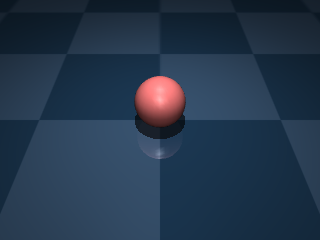

✅ Projectile model loaded!
Gravity: [ 0.    0.   -9.81] m/s²
Ball mass: 5.00 kg


In [17]:
# Cell 2: Define the projectile motion XML
XML = """
<mujoco>
  <asset>
    <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3"
     rgb2=".2 .3 .4" width="300" height="300"/>
    <material name="grid" texture="grid" texrepeat="8 8" reflectance=".2"/>
  </asset>

  <worldbody>
    <geom name="ground" size="10 10 .01" type="plane" material="grid" friction="0 0 0"/>
    <light pos="0 0 5"/>
	<body pos="0 0 .25">
		<freejoint/>
		<geom name="ball0" type="sphere" size=".25 .25 .25" rgba="1 .5 .5 1" mass="5" friction="0 0 0"/>
	</body>
  </worldbody>

</mujoco>
"""

model = mujoco.MjModel.from_xml_string(XML)
data  = mujoco.MjData(model)
print(f"nbody = {model.nbody}, nv = {model.nv}")

with mujoco.Renderer(model) as renderer:
  mujoco.mj_forward(model, data)
  renderer.update_scene(data)

  media.show_image(renderer.render())

print("✅ Projectile model loaded!")
print(f"Gravity: {model.opt.gravity} m/s²")
print(f"Ball mass: {model.body_mass[1]:.2f} kg")  # projectile is body index 1

In [25]:
# Cell 3: Create a class to manage projectile motion
class ProjectileMotion:
    def __init__(self, model, data):
        self.model = model
        self.data = data
        self.trajectory_x = []
        self.trajectory_z = []
        self.times = []
        self.velocities_x = []
        self.velocities_z = []
        
    def launch(self, v0_x, v0_z, initial_x=0, initial_z=0.25):
        """
        Launch the projectile with initial velocity
        
        Parameters:
        v0_x: initial horizontal velocity (m/s)
        v0_z: initial vertical velocity (m/s)
        initial_x: initial x position (m)
        initial_z: initial z position (m)
        """
        # Reset simulation
        self.data = mujoco.MjData(self.model)
        
        # Set initial position
        self.data.qpos[0] = initial_x  # x position
        self.data.qpos[1] = 0          # y position (0 for 2D)
        self.data.qpos[2] = initial_z  # z position (height)
        
        # Set initial velocity (freejoint: vx, vy, vz, wx, wy, wz)
        self.data.qvel[0] = v0_x        # linear x velocity
        self.data.qvel[1] = 0           # linear y velocity
        self.data.qvel[2] = v0_z        # linear z velocity
        self.data.qvel[3] = 0           # angular velocity x
        self.data.qvel[4] = 0           # angular velocity y
        self.data.qvel[5] = 0           # angular velocity z
        
        # Store launch parameters
        self.v0_x = v0_x
        self.v0_z = v0_z
        self.initial_x = initial_x
        self.initial_z = initial_z
        
        # Clear trajectory data
        self.trajectory_x = []
        self.trajectory_z = []
        self.times = []
        self.velocities_x = []
        self.velocities_z = []
        
        print(f"🚀 Projectile Launched!")
        print(f"   Initial position: ({initial_x}, {initial_z}) m")
        print(f"   Initial velocity: ({v0_x}, {v0_z}) m/s")
        print(f"   Speed: {np.sqrt(v0_x**2 + v0_z**2):.2f} m/s")
        print(f"   Launch angle: {np.arctan2(v0_z, v0_x) * 180 / np.pi:.1f}°")
        
    def simulate(self, max_time=10.0, record_trajectory=True):
        """
        Run simulation and record trajectory
        """
        if record_trajectory:
            self.trajectory_x = []
            self.trajectory_z = []
            self.times = []
            self.velocities_x = []
            self.velocities_z = []
        
        steps = int(max_time / self.model.opt.timestep)
        
        for step in range(steps):
            if record_trajectory:
                self.times.append(self.data.time)
                self.trajectory_x.append(self.data.qpos[0])
                self.trajectory_z.append(self.data.qpos[2])
                self.velocities_x.append(self.data.qvel[0])
                self.velocities_z.append(self.data.qvel[2])
            
            # Stop if ball hits ground (z < 0.05)
            if self.data.qpos[2] <= 0.25 and step > 10:
                break
                
            mujoco.mj_step(self.model, self.data)
            
        if record_trajectory:
            print(f"✅ Simulation complete! Flight time: {self.data.time:.2f} seconds")
            print(f"   Range: {self.data.qpos[0] - self.initial_x:.2f} m")
            print(f"   Max height: {max(self.trajectory_z):.2f} m")
        
        return self.data.time
        
    def get_theoretical_trajectory(self):
        """
        Calculate theoretical trajectory (without air resistance)
        """
        g = 9.81
        
        # Time of flight
        t_flight = 2 * self.v0_z / g
        t = np.linspace(0, t_flight, 100)
        
        # Theoretical equations
        x_theory = self.initial_x + self.v0_x * t
        z_theory = self.initial_z + self.v0_z * t - 0.5 * g * t**2
        
        # Remove negative heights
        valid = z_theory >= 0
        return t[valid], x_theory[valid], z_theory[valid]
    
    def plot_trajectory(self):
        """
        Plot the trajectory and analysis
        """
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Trajectory plot
        axes[0,0].plot(self.trajectory_x, self.trajectory_z, 'b-', linewidth=2, label='Simulated')
        
        # Add theoretical trajectory
        t_theory, x_theory, z_theory = self.get_theoretical_trajectory()
        axes[0,0].plot(x_theory, z_theory, 'r--', linewidth=2, label='Theoretical')
        
        axes[0,0].scatter([self.initial_x], [self.initial_z], color='g', s=100, 
                         marker='o', label='Launch point', zorder=5)
        axes[0,0].scatter([self.trajectory_x[-1]], [self.trajectory_z[-1]], 
                         color='r', s=100, marker='x', label='Landing point', zorder=5)
        
        axes[0,0].set_xlabel('X Position (m)')
        axes[0,0].set_ylabel('Z Position (m)')
        axes[0,0].set_title('Projectile Trajectory')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        axes[0,0].set_aspect('equal')
        
        # Height vs Time
        axes[0,1].plot(self.times, self.trajectory_z, 'g-', linewidth=2)
        axes[0,1].set_xlabel('Time (s)')
        axes[0,1].set_ylabel('Height (m)')
        axes[0,1].set_title('Height vs Time')
        axes[0,1].grid(True, alpha=0.3)
        
        # Horizontal Velocity vs Time
        axes[1,0].plot(self.times, self.velocities_x, 'b-', linewidth=2)
        axes[1,0].axhline(y=self.v0_x, color='r', linestyle='--', 
                         label=f'Theoretical: {self.v0_x:.1f} m/s (constant)')
        axes[1,0].set_xlabel('Time (s)')
        axes[1,0].set_ylabel('Horizontal Velocity (m/s)')
        axes[1,0].set_title('Horizontal Velocity vs Time')
        axes[1,0].legend()
        axes[1,0].grid(True, alpha=0.3)
        
        # Vertical Velocity vs Time
        axes[1,1].plot(self.times, self.velocities_z, 'r-', linewidth=2)
        t_theory_vel = np.linspace(0, self.data.time, 100)
        vz_theory = self.v0_z - 9.81 * t_theory_vel
        axes[1,1].plot(t_theory_vel, vz_theory, 'g--', linewidth=2, label='Theoretical')
        axes[1,1].axhline(y=0, color='k', linestyle=':', linewidth=1)
        axes[1,1].set_xlabel('Time (s)')
        axes[1,1].set_ylabel('Vertical Velocity (m/s)')
        axes[1,1].set_title('Vertical Velocity vs Time')
        axes[1,1].legend()
        axes[1,1].grid(True, alpha=0.3)
        
        plt.suptitle(f'2D Projectile Motion (v0=({self.v0_x:.1f}, {self.v0_z:.1f}) m/s, angle={np.arctan2(self.v0_z, self.v0_x)*180/np.pi:.1f}°)', 
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
    def print_analysis(self):
        """
        Print detailed analysis of the projectile motion
        """
        g = -self.model.opt.gravity[2]
        
        # Theoretical calculations
        t_flight_theory = 2 * self.v0_z / g
        range_theory = self.v0_x * t_flight_theory
        max_height_theory = self.initial_z + (self.v0_z**2) / (2 * g)
        
        # Simulated results
        t_flight_sim = self.data.time
        range_sim = self.trajectory_x[-1] - self.initial_x
        max_height_sim = max(self.trajectory_z)
        
        print("\n" + "="*60)
        print("PROJECTILE MOTION ANALYSIS")
        print("="*60)
        print(f"\nLaunch Parameters:")
        print(f"  Initial velocity: ({self.v0_x:.2f}, {self.v0_z:.2f}) m/s")
        print(f"  Launch speed: {np.sqrt(self.v0_x**2 + self.v0_z**2):.2f} m/s")
        print(f"  Launch angle: {np.arctan2(self.v0_z, self.v0_x) * 180 / np.pi:.1f}°")
        
        print(f"\nResults:")
        print(f"  {'Parameter':<20} {'Simulated':<15} {'Theoretical':<15} {'Error':<10}")
        print(f"  {'-'*55}")
        print(f"  {'Flight time (s)':<20} {t_flight_sim:<15.2f} {t_flight_theory:<15.2f} {abs(t_flight_sim-t_flight_theory)/t_flight_theory*100:<10.2f}%")
        print(f"  {'Range (m)':<20} {range_sim:<15.2f} {range_theory:<15.2f} {abs(range_sim-range_theory)/range_theory*100:<10.2f}%")
        print(f"  {'Max height (m)':<20} {max_height_sim:<15.2f} {max_height_theory:<15.2f} {abs(max_height_sim-max_height_theory)/max_height_theory*100:<10.2f}%")
        
        # Energy analysis
        mass = 0.5
        ke_initial = 0.5 * mass * (self.v0_x**2 + self.v0_z**2)
        pe_initial = mass * g * self.initial_z
        total_energy_initial = ke_initial + pe_initial
        
        # Final energy (just before impact)
        vf_x = self.velocities_x[-1]
        vf_z = self.velocities_z[-1]
        ke_final = 0.5 * mass * (vf_x**2 + vf_z**2)
        pe_final = mass * g * self.trajectory_z[-1]
        total_energy_final = ke_final + pe_final
        
        energy_loss = (total_energy_initial - total_energy_final) / total_energy_initial * 100
        
        print(f"\nEnergy Analysis:")
        print(f"  Initial total energy: {total_energy_initial:.2f} J")
        print(f"  Final total energy: {total_energy_final:.2f} J")
        print(f"  Energy loss (due to impact): {energy_loss:.2f}%")

EXAMPLE 1: Cannonball (26.6° angle)
🚀 Projectile Launched!
   Initial position: (0, 0.1) m
   Initial velocity: (20.0, 10.0) m/s
   Speed: 22.36 m/s
   Launch angle: 26.6°
✅ Simulation complete! Flight time: 2.02 seconds
   Range: 40.44 m
   Max height: 5.19 m


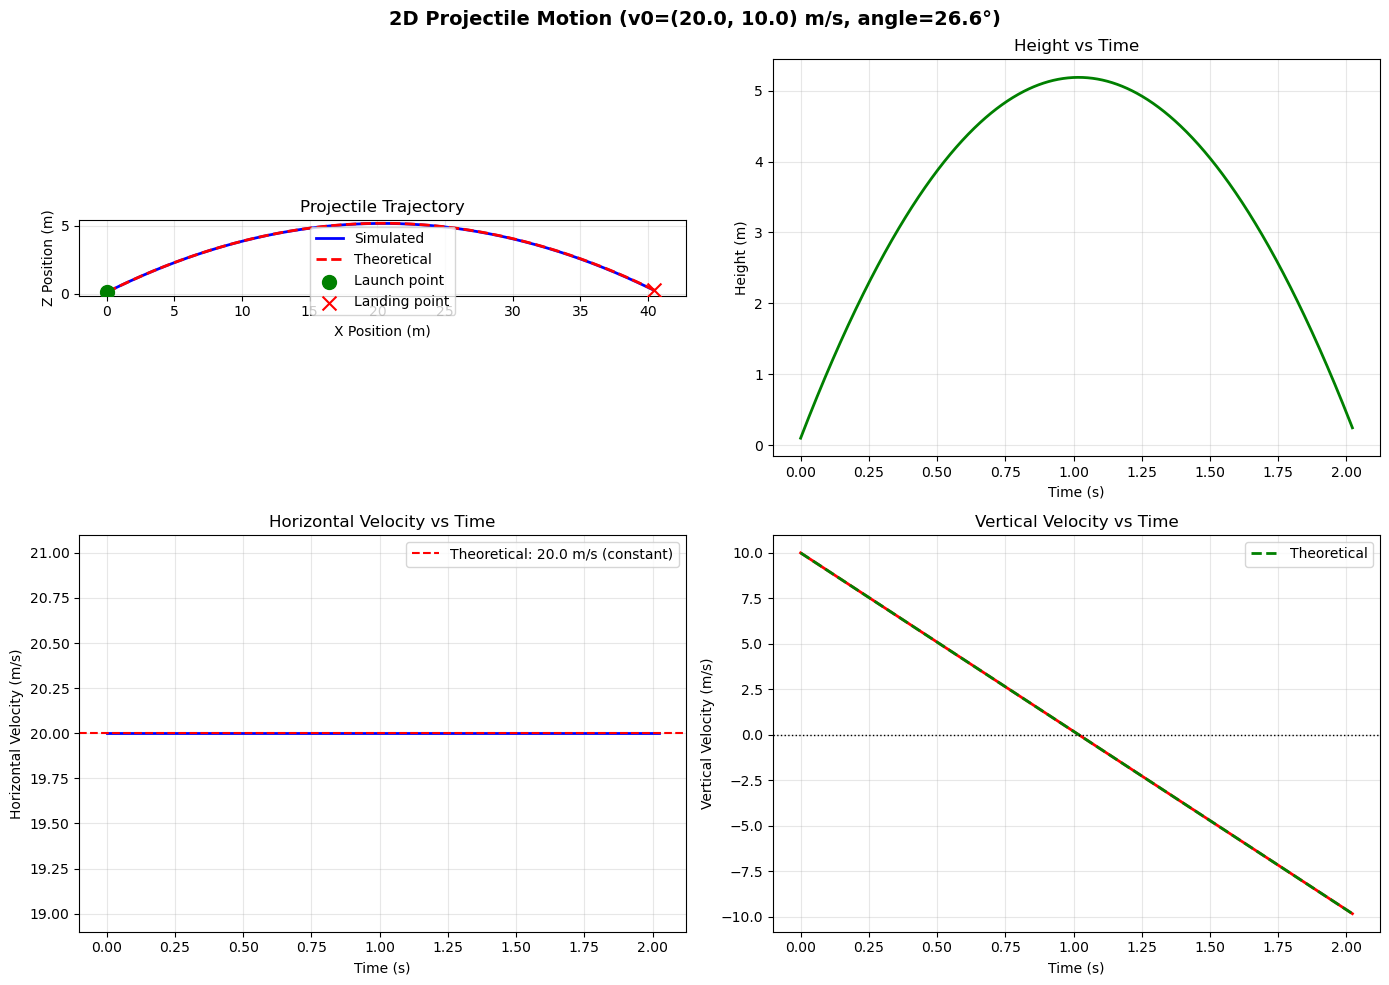


PROJECTILE MOTION ANALYSIS

Launch Parameters:
  Initial velocity: (20.00, 10.00) m/s
  Launch speed: 22.36 m/s
  Launch angle: 26.6°

Results:
  Parameter            Simulated       Theoretical     Error     
  -------------------------------------------------------
  Flight time (s)      2.02            2.04            0.82      %
  Range (m)            40.44           40.77           0.82      %
  Max height (m)       5.19            5.20            0.19      %

Energy Analysis:
  Initial total energy: 125.49 J
  Final total energy: 125.39 J
  Energy loss (due to impact): 0.08%


In [26]:
# Cell 4: Interactive projectile launch (run multiple scenarios)
def launch_projectile(vx, vz, show_plot=True):
    """
    Launch projectile with given velocities and display results
    """
    projectile = ProjectileMotion(model, data)
    projectile.launch(v0_x=vx, v0_z=vz, initial_x=0, initial_z=0.1)
    projectile.simulate(max_time=10.0)
    
    if show_plot:
        projectile.plot_trajectory()
        projectile.print_analysis()
    
    return projectile

# Example launches
print("="*60)
print(f"EXAMPLE 1: Cannonball ({np.arctan2(10, 20)*180/np.pi:.1f}° angle)")
print("="*60)
p1 = launch_projectile(vx=20.0, vz=10.0)